<a href="https://colab.research.google.com/github/2401020564-debug/CREDIT-PREDICTION/blob/main/Give_Me_Some_Credit_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Step 1: Download and Upload the Dataset**
* Go to the "Give Me Some Credit" Kaggle page and click Download All.

* Extract the downloaded ZIP file on your computer.

* Open your Google Colab notebook. On the left-hand sidebar, click the Folder icon (Files).

* Click the Upload icon (a page with an up arrow) and select cs-training.csv and cs-test.csv from your extracted folder to upload them to your Colab
environment.


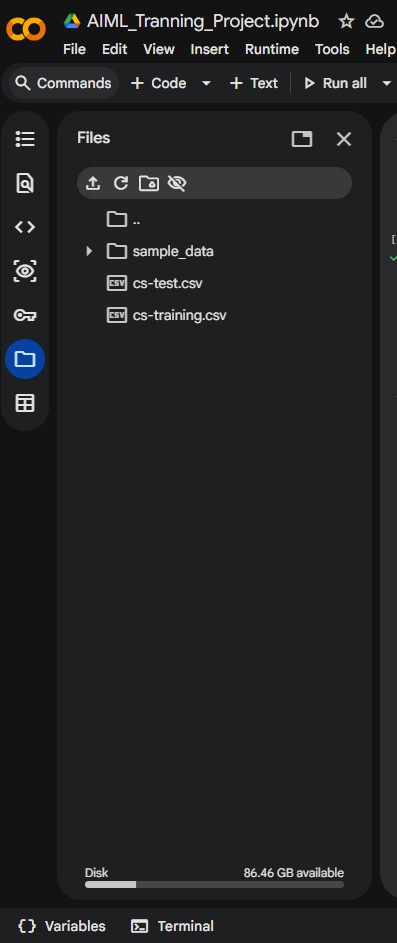

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train = pd.read_csv("/content/cs-training.csv")
test = pd.read_csv("/content/cs-test.csv")

train.drop('Unnamed: 0', axis=1, inplace=True)
test_ids = test['Unnamed: 0']
test.drop('Unnamed: 0', axis=1, inplace=True)

train.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


# Step 2: Exploratory Data Analysis (EDA)
Before building a model, it is crucial to understand the data's shape and where we might have missing values.

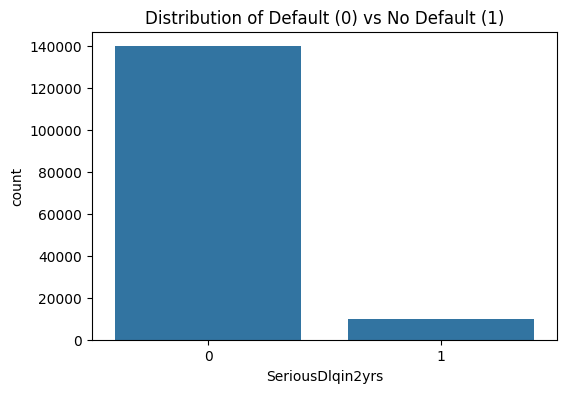

Missing values in Training Data:
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64


In [16]:
plt.figure(figsize=(6, 4))
sns.countplot(x='SeriousDlqin2yrs', data=train)
plt.title('Distribution of Default (0) vs No Default (1)')
plt.show()

print("Missing values in Training Data:")
print(train.isnull().sum())

# Step 3: Data Preprocessing
Based on our EDA, we know MonthlyIncome and NumberOfDependents have missing values. We will fill these gaps using the median value of each column so we don't lose valuable training data.

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

X = train.drop('SeriousDlqin2yrs', axis=1)
y = train['SeriousDlqin2yrs']

missing_cols = ['MonthlyIncome', 'NumberOfDependents']

imputer = SimpleImputer(strategy='median')
X[missing_cols] = imputer.fit_transform(X[missing_cols])

X_test = test.drop('SeriousDlqin2yrs', axis=1)
X_test[missing_cols] = imputer.transform(X_test[missing_cols])

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Step 4: Model Building
We are using XGBoost because it handles tabular data incredibly well and has built-in parameters to help deal with the class imbalance we saw in Step 2.

In [18]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=14,
    random_state=42
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

# Step 5: Model Evaluation
We will use the ROC-AUC score to evaluate our model, as this is the metric Kaggle uses for this specific competition.

Validation ROC-AUC Score: 0.8689


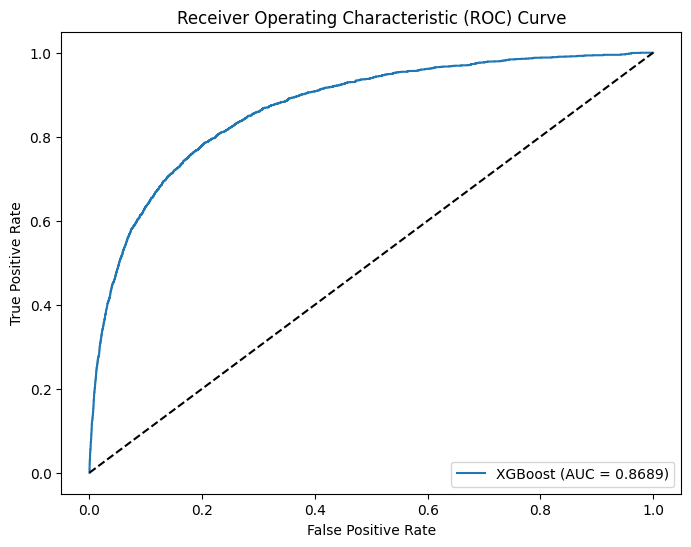

In [19]:
from sklearn.metrics import roc_auc_score, roc_curve

val_preds = model.predict_proba(X_val)[:, 1]

auc_score = roc_auc_score(y_val, val_preds)
print(f"Validation ROC-AUC Score: {auc_score:.4f}")

fpr, tpr, _ = roc_curve(y_val, val_preds)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

# Step 6: Generate Kaggle Submission
Finally, we format our predictions on the unseen test data to match Kaggle's exact requirements.

In [20]:
test_preds = model.predict_proba(X_test)[:, 1]

submission = pd.DataFrame({
    'Id': test_ids,
    'Probability': test_preds
})

submission.to_csv('submission.csv', index=False)
print("Submission successfully saved to submission.csv")

Submission successfully saved to submission.csv
